# Fragmentation Analysis

In [30]:
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd

## Administrative Boundaries

adm1 shape: (10, 22)
adm2 shape: (58, 27)
adm3 shape: (360, 32)


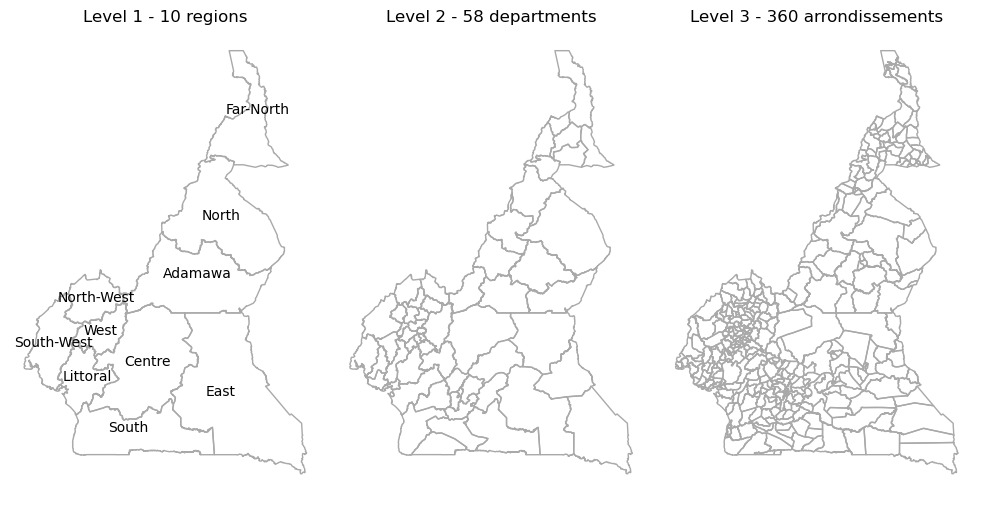

In [31]:
# set this to the folder where you unzipped the files
data_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")

# read shapefiles for each admin level
adm1 = gpd.read_file(data_dir / "cmr_admin1.shp")
adm2 = gpd.read_file(data_dir / "cmr_admin2.shp")
adm3 = gpd.read_file(data_dir / "cmr_admin3.shp")

# quick check: print table size
print("adm1 shape:", adm1.shape)
print("adm2 shape:", adm2.shape)
print("adm3 shape:", adm3.shape)

# quick check: print head
# print(adm1.head())
# print(adm2.head())
# print(adm3.head())

# simple separate plots
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

adm1.plot(ax=axes[0], edgecolor="darkgray", facecolor="none")
axes[0].set_title(f"Level 1 - {len(adm1)} regions")

# add region labels (only level 1)
for _, row in adm1.iterrows():
    p = row.geometry.representative_point()
    axes[0].text(
        p.x, p.y, row["adm1_name"],
        fontsize=10, ha="center", va="center"
    )

adm2.plot(ax=axes[1], edgecolor="darkgray", facecolor="none")
axes[1].set_title(f"Level 2 - {len(adm2)} departments")

adm3.plot(ax=axes[2], edgecolor="darkgray", facecolor="none")
axes[2].set_title(f"Level 3 - {len(adm3)} arrondissements")

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


In [32]:
adm2.head()

,adm2_name,adm2_name1,adm2_name2,adm2_name3,adm2_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,...,area_sqkm,version,lang,lang1,lang2,lang3,adm2_ref_n,center_lat,center_lon,geometry
0,None,Bamboutos,None,None,CM008001,West,Ouest,None,None,CM008,...,1172.596364,v01,en,fr,None,None,Bamboutos,5.667776,10.292618,"POLYGON ((10.5231 5.83428, 10.5356 5.82398, 10..."
1,None,Bénoué,None,None,CM006001,North,Nord,None,None,CM006,...,13668.222784,v01,en,fr,None,None,Benoue,9.177869,13.438456,"POLYGON ((13.32926 9.99781, 13.33297 9.99621, ..."
2,None,Boumba-et-Ngoko,None,None,CM003001,East,Est,None,None,CM003,...,31753.233383,v01,en,fr,None,None,Boumba-et-Ngoko,2.836623,15.199602,"POLYGON ((15.07438 4.02051, 15.33855 3.71095, ..."
3,None,Boyo,None,None,CM007001,North-West,Nord-Ouest,None,None,CM007,...,1651.033282,v01,en,fr,None,None,Boyo,6.407576,10.423244,"POLYGON ((10.45446 6.68754, 10.45421 6.68609, ..."
4,None,Bui,None,None,CM007002,North-West,Nord-Ouest,None,None,CM007,...,2211.378475,v01,en,fr,None,None,Bui,6.228028,10.715305,"POLYGON ((10.60626 6.47313, 10.60696 6.47298, ..."


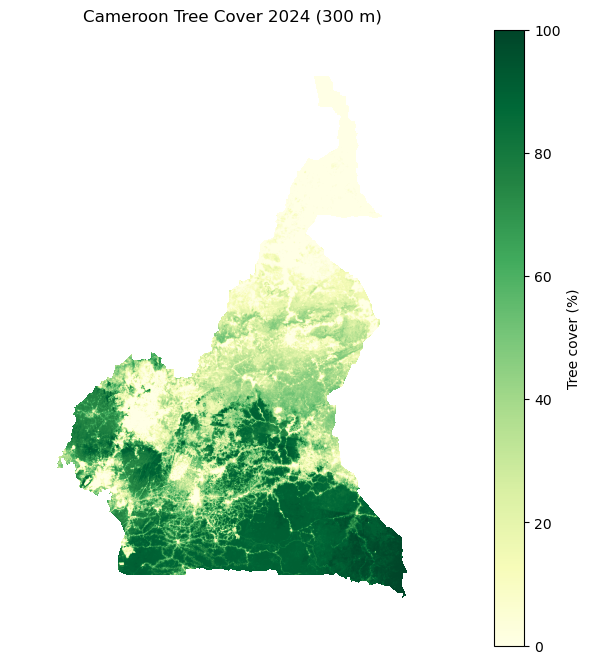

In [33]:
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from affine import Affine

treecover_path = Path("../data/output/processed-hansen-treecover/cameroon_treecover2024_30m.tif")
adm0 = gpd.read_file(data_dir / "cmr_admin0.shp")

with rasterio.open(treecover_path) as src:
    scale = 10  # 30 m -> 300 m
    out_height = src.height // scale
    out_width = src.width // scale
    out_transform = src.transform * Affine.scale(scale, scale)
    treecover = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average,
        masked=True,
    )
    nodata = src.nodata

# Mask pixels outside Cameroon boundary
outside = geometry_mask(adm0.geometry, transform=out_transform, invert=False, out_shape=treecover.shape)
treecover = np.ma.masked_where(outside, treecover)

plt.figure(figsize=(10, 8))
im = plt.imshow(treecover, cmap="YlGn", vmin=0, vmax=100)
plt.title("Cameroon Tree Cover 2024 (300 m)")
plt.colorbar(im, label="Tree cover (%)")
plt.axis("off")
plt.show()

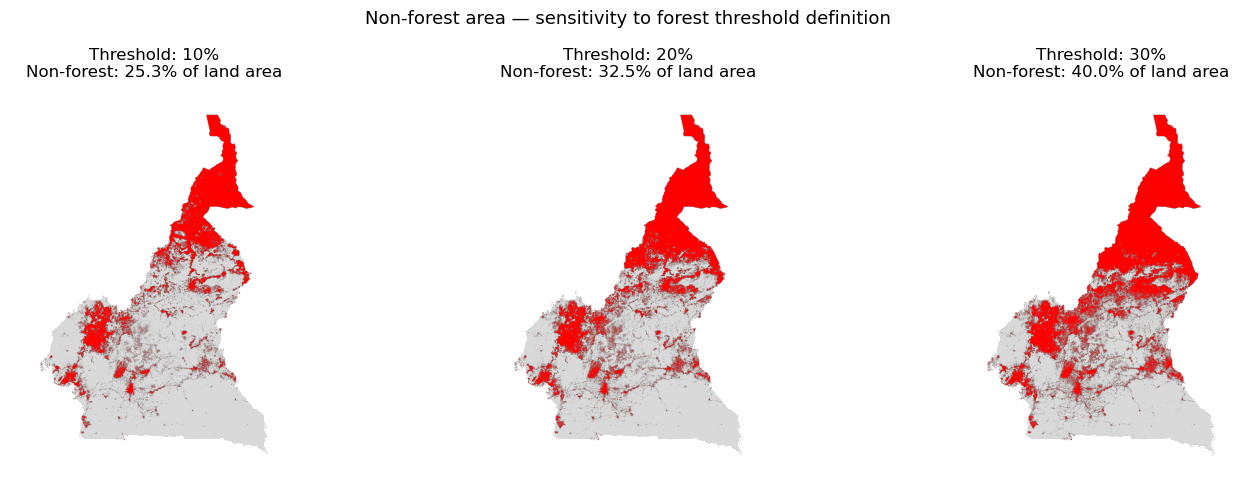

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, threshold in zip(axes, [10, 20, 30]):
    # Light gray background for Cameroon land area
    land = np.where(~treecover.mask, 0.85, np.nan)
    ax.imshow(land, cmap="gray", vmin=0, vmax=1)

    # Non-forest: valid pixels strictly below the threshold
    non_forest = (~treecover.mask) & (treecover.filled(0) < threshold)

    # Overlay non-forest pixels in red via RGBA
    rgba = np.zeros((*treecover.shape, 4), dtype=float)
    rgba[non_forest] = [1, 0, 0, 1]
    ax.imshow(rgba)

    # Percentage of land area that is non-forest
    pct = 100 * non_forest.sum() / (~treecover.mask).sum()
    ax.set_title(f"Threshold: {threshold}%\nNon-forest: {pct:.1f}% of land area")
    ax.axis("off")

plt.suptitle("Non-forest area — sensitivity to forest threshold definition", fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# Aggregate tree cover by administrative level
treecover_by_adm1 = []
treecover_by_adm2 = []
treecover_by_adm3 = []

for _, row in adm1.iterrows():
    with rasterio.open(treecover_path) as src:
        masked_data, _ = rasterio.mask.mask(src, [row.geometry], crop=True, filled=False)
    treecover_by_adm1.append({
        'adm1_name': row['adm1_name'],
        'mean_treecover': float(np.ma.mean(masked_data))
    })

for _, row in adm2.iterrows():
    try:
        with rasterio.open(treecover_path) as src:
            masked_data, _ = rasterio.mask.mask(src, [row.geometry], crop=True, filled=False)
        treecover_by_adm2.append({
            'adm2_name': row['adm2_name1'],
            'mean_treecover': float(np.ma.mean(masked_data))
        })
    except ValueError:
        pass

for _, row in adm3.iterrows():
    try:
        with rasterio.open(treecover_path) as src:
            masked_data, _ = rasterio.mask.mask(src, [row.geometry], crop=True, filled=False)
        treecover_by_adm3.append({
            'adm3_name': row['adm3_name1'],
            'mean_treecover': float(np.ma.mean(masked_data))
        })
    except ValueError:
        pass

# Create dataframes
df_adm1 = pd.DataFrame(treecover_by_adm1)
df_adm2 = pd.DataFrame(treecover_by_adm2)
df_adm3 = pd.DataFrame(treecover_by_adm3)

# Merge back to geodataframes for plotting
adm1_with_cover = adm1.merge(df_adm1, left_on='adm1_name', right_on='adm1_name', how='left')
adm2_with_cover = adm2.merge(df_adm2, left_on='adm2_name1', right_on='adm2_name', how='left')
adm3_with_cover = adm3.merge(df_adm3, left_on='adm3_name1', right_on='adm3_name', how='left')

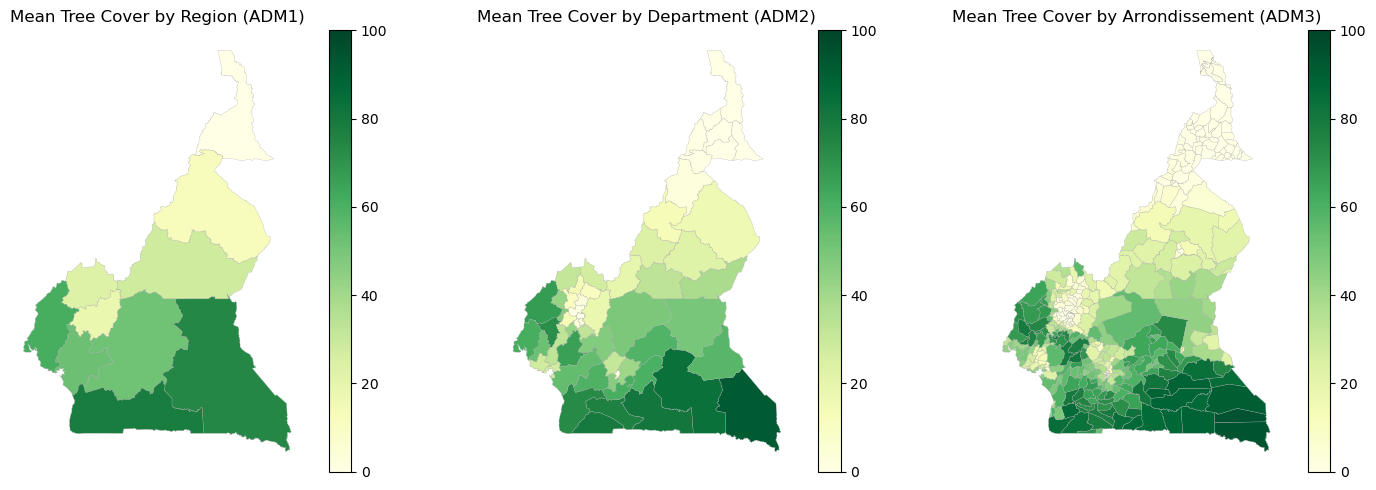

In [36]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

adm1_with_cover.plot(column='mean_treecover', ax=axes[0], cmap='YlGn', vmin=0, vmax=100,
                     edgecolor='darkgray', legend=True, linewidth=0.2)
axes[0].set_title('Mean Tree Cover by Region (ADM1)')
axes[0].set_axis_off()

adm2_with_cover.plot(column='mean_treecover', ax=axes[1], cmap='YlGn', vmin=0, vmax=100,
                     edgecolor='darkgray', legend=True, linewidth=0.2)
axes[1].set_title('Mean Tree Cover by Department (ADM2)')
axes[1].set_axis_off()

adm3_with_cover.plot(column='mean_treecover', ax=axes[2], cmap='YlGn', vmin=0, vmax=100,
                     edgecolor='darkgray', legend=True, linewidth=0.2)
axes[2].set_title('Mean Tree Cover by Arrondissement (ADM3)')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

In [37]:
# Print summary statistics
print("\nAdministrative Level 1 (Regions) - Tree Cover Summary:")
print(df_adm1.sort_values('mean_treecover', ascending=False))
print("\nAdministrative Level 2 (Departments) - Top 10:")
print(df_adm2.sort_values('mean_treecover', ascending=False).head(10))
print("\nAdministrative Level 3 (Arrondissements) - Top 10:")
print(df_adm3.sort_values('mean_treecover', ascending=False).head(10))


Administrative Level 1 (Regions) - Tree Cover Summary:
    adm1_name  mean_treecover
7       South       77.917036
2        East       74.190749
8  South-West       60.974002
4    Littoral       52.406820
1      Centre       51.737917
0     Adamawa       28.017603
6  North-West       23.403015
9        West       18.226739
5       North       11.943914
3   Far-North        0.164570

Administrative Level 2 (Departments) - Top 10:
          adm2_name  mean_treecover
2   Boumba-et-Ngoko       91.913140
13       Haut-Nyong       83.455257
6       Dja-et-Lobo       80.708177
55   Vallée-du-Ntem       79.421208
44            Mvila       76.871045
53            Océan       72.883141
18   Kupe-Manenguba       71.963160
23            Manyu       67.359752
48             Nkam       65.991638
52    Nyong-et-So'o       61.254404

Administrative Level 3 (Arrondissements) - Top 10:
      adm3_name  mean_treecover
317  Salapoumbe       94.562333
238   Moloundou       94.371680
356   Yokadouma       

# Forest Patches Detection